In [1]:
pip install transformers torch accelerate sentencepiece

  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   -------------------- ------------------- 5.8/11.2 MB 30.1 MB/s eta 0:00:01
   ----------------------------------- ---- 10.0/11.2 MB 24.3 MB/s eta 0:00:01
   ---------------------------------------- 11.2/11.2 MB 21.2 MB/s  0:00:00
   ---------------------------------------- 0.0/693.4 kB ? eta -:--:--
   ---------------------------------------- 693.4/693.4 kB 15.9 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 27.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 21.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 22.6 MB/s  0:00:00
Using cached click-8.4.1-py3-none-any.whl (116 kB)

   --


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [13]:
model_name="gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [27]:
prompt="Capital of India is"

inputs=tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs=model(**inputs)
logits=outputs.logits

In [28]:
print(logits.shape)

torch.Size([1, 4, 50257])


[Batch Size, Sequence Length, Vocabulary Size]

**Batch size**-> no. of sentences/sequences (here 1)
**Sequence length**-> no. of token/words (here 4)
**Vocabulary Size**-> total no. of tokens (here 50257)

In [34]:
next_token_logits = logits[0, -1]

In [30]:
probs=torch.softmax(
    next_token_logits, 
    dim=-1
)

print(probs.sum())

tensor(1.0000)


In [31]:
values, indices = torch.topk(
    probs, 
    k=10
)

In [32]:
for p, idx in zip(values, indices):
    token = tokenizer.decode(idx)

    print(
        token, 
        float(p)
    )

 a 0.08810127526521683
 the 0.07456322014331818
 now 0.03157976642251015
 one 0.02858331799507141
 an 0.02284274250268936
 not 0.022712409496307373
 in 0.019446825608611107
 also 0.01872381381690502
 currently 0.012788030318915844
 set 0.009783403016626835


In [33]:
entropy = -torch.sum(
    probs* torch.log(probs + 1e-12)
)

print(entropy.item())

6.088840007781982


A logit is a raw, unnormalized, prediction score generated by a transformer, for every possible output/ class.
We then apply softmax to convert these logits into a clean, organized probability distribution.

In [50]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "The capital of France is"

inputs = tokenizer(prompt, return_tensors="pt")

output = model.generate(
    **inputs,
    max_new_tokens=20,
    return_dict_in_generate=True,
    output_scores=True
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [51]:
generated_ids = output.sequences[0]

text = tokenizer.decode(
    generated_ids,
    skip_special_tokens=True
)

print(text)

The capital of France is the capital of the French Republic, and the capital of the French Republic is the capital of the French


In [52]:
print(len(output.scores))

20


In [53]:
generated_part=generated_ids[
    inputs.input_ids.shape[1]:
    ]

In [59]:
tokens=[]
token_probs=[]
entropies=[]
for token_id, score in zip(
    generated_part,
    output.scores
):
    probs=torch.softmax(
        score[0],
        dim=-1
    )

    token_prob=probs[token_id]

    entropy=-torch.sum(
        probs*torch.log(probs+1e-12)
    )

    token_probs.append(
        float(token_prob)
    )
    entropies.append(
        entropy.item()
    )
    tokens.append(token)
    token=tokenizer.decode(token_id)

    print(
        token, 
        float(token_prob), 
        entropy.item()
    )

 the 0.08459208905696869 5.998455047607422
 capital 0.1696840524673462 5.892510414123535
 of 0.9270868301391602 0.5376878976821899
 the 0.282778263092041 4.432570457458496
 French 0.13667923212051392 6.169736862182617
 Republic 0.3006313741207123 4.052666187286377
, 0.3391307294368744 2.2030529975891113
 and 0.280984103679657 4.012385845184326
 the 0.16335880756378174 4.828832626342773
 capital 0.10518389940261841 6.544045448303223
 of 0.9411987662315369 0.4911474883556366
 the 0.396868497133255 3.02215576171875
 French 0.21279394626617432 4.390183448791504
 Republic 0.5285288095474243 2.768136739730835
 is 0.5112079381942749 2.951442241668701
 the 0.30543315410614014 4.048369884490967
 capital 0.5358341336250305 3.498307466506958
 of 0.9748329520225525 0.23328562080860138
 the 0.43073007464408875 2.4884049892425537
 French 0.29461216926574707 3.6482620239257812


In [60]:
import numpy as np
var_prob=np.var(token_probs)

In [61]:
print("Mean Probability:", np.mean(token_probs))
print("Min Probability:", np.min(token_probs))

print("Mean Entropy:", np.mean(entropies))
print("Max Entropy:", np.max(entropies))

Mean Probability: 0.3961074911057949
Min Probability: 0.08459208905696869
Mean Entropy: 3.610581972450018
Max Entropy: 6.544045448303223


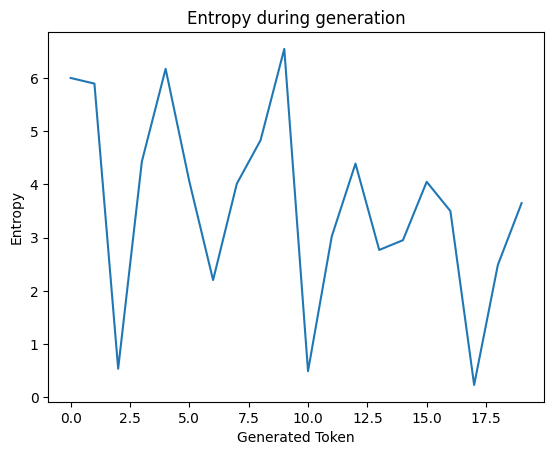

In [62]:
import matplotlib.pyplot as pyplot

pyplot.plot(entropies)
pyplot.xlabel("Generated Token")
pyplot.ylabel("Entropy")
pyplot.title("Entropy during generation")
pyplot.show()

### **Graph Inference:** 
Hallucinated or incorrect generations may contain more high-entropy regions than correct generations.

In [64]:
for token, prob, ent in zip(
    tokens,
    token_probs,
    entropies
):
    print(
        f"{repr(token):<20} "
        f"Prob={prob:.4f} "
        f"Entropy={ent:.4f}"
    )

' French'            Prob=0.0846 Entropy=5.9985
' the'               Prob=0.1697 Entropy=5.8925
' capital'           Prob=0.9271 Entropy=0.5377
' of'                Prob=0.2828 Entropy=4.4326
' the'               Prob=0.1367 Entropy=6.1697
' French'            Prob=0.3006 Entropy=4.0527
' Republic'          Prob=0.3391 Entropy=2.2031
','                  Prob=0.2810 Entropy=4.0124
' and'               Prob=0.1634 Entropy=4.8288
' the'               Prob=0.1052 Entropy=6.5440
' capital'           Prob=0.9412 Entropy=0.4911
' of'                Prob=0.3969 Entropy=3.0222
' the'               Prob=0.2128 Entropy=4.3902
' French'            Prob=0.5285 Entropy=2.7681
' Republic'          Prob=0.5112 Entropy=2.9514
' is'                Prob=0.3054 Entropy=4.0484
' the'               Prob=0.5358 Entropy=3.4983
' capital'           Prob=0.9748 Entropy=0.2333
' of'                Prob=0.4307 Entropy=2.4884
' the'               Prob=0.2946 Entropy=3.6483


### **Inference:**

high confidence-> low entropy

low confidence-> high entropy


## Does entropy differ between easy factual completions and harder completions?

In [105]:
prompts1=[   #easy factual prompts
    "What is 2+2=?",
    "What is the freezing point of water?",
    "Which is the largest planet?",
    "What is the capital of India?",
    "Is theory of relativity true?",
    "Who is the president of India?",
    "When did India gain independence",
    "What is the square root of 25?",
    "Who won orange cap in IPL 2016?",
    "How far is sun from earth?"
]

prompts2=[   #hard logic and reasoning prompts
    "I want to wash my car. The car wash is 50 m away. Should I walk or drive?",
    "779,678 * 866,978=?",
    "What is 'elbow' spelled backwards?",
    "I do not not not like eggs. Do I like eggs?",
    "Sally is a girl. She has 3 brothers. Each brother has 2 sisters. How many sisters does Sally have?",
    "Given a QWERTY keyboard layout, if HEART goes to JRSTY, what does AFTER go to?",
    "Which word comes next: Stone, Often, Canine, _: A Helpful B Freight C Glow D Grape",
    "Five monkeys are jumping around on a four poster bed while three chickens stand and watch. How many legs are on the floor?",
    "In a room there are only three sisters. Anna is reading a book. Alice is playing chess. What is the third sister, Amanda doing?",
    "How many boxes do I have if I have two boxes with one box inside each?"
]

In [106]:
def analyze_generation(prompt):
    
    inputs = tokenizer(prompt, return_tensors="pt")

    output = model.generate(
        **inputs,
        max_new_tokens=50,
        return_dict_in_generate=True,
        output_scores=True,
        pad_token_id=tokenizer.eos_token_id #surpass the pad warning
    )

    generated_ids = output.sequences[0]

    generated_part = generated_ids[
        inputs.input_ids.shape[1]:
    ]

    token_probs = []
    entropies = []

    for token_id, score in zip(
        generated_part,
        output.scores
    ):

        probs = torch.softmax(score[0], dim=-1)

        token_prob = probs[token_id]

        entropy = -torch.sum(
            probs * torch.log(probs + 1e-12)
        )

        token_probs.append(float(token_prob))
        entropies.append(float(entropy))

    generated_text= tokenizer.decode(
        generated_part,
        skip_special_tokens=True
    )
    
    return {
        "generated_text": generated_text,
        "mean_entropy": np.mean(entropies),
        "max_entropy": np.max(entropies),
        "mean_prob": np.mean(token_probs),
        "min_prob": np.min(token_probs)
    }

In [107]:
results = []

for prompt in prompts1:

    stats = analyze_generation(prompt)

    stats["prompt"] = prompt

    results.append(stats)

import pandas as pd

df1 = pd.DataFrame(results)

print(df1)

                                      generated_text  mean_entropy  \
0  \n\nThe answer is 2+2=1.\n\nThe answer is 2+2=...      1.538449   
1  \n\nThe freezing point of water is the point a...      2.306393   
2  \n\nThe largest planet is the Earth. It's the ...      2.164484   
3  \n\nIndia is the world's largest economy. It i...      1.816319   
4  \n\nThe answer is that the theory of relativit...      2.950736   
5  \n\nThe president of India is the president of...      1.521314   
6   from Britain?\n\nThe British Empire was a col...      2.876565   
7  \n\nThe square root of 25 is the number of tim...      2.241298   
8  \n\nThe answer is yes.\n\nThe team that won th...      2.751585   
9  \n\nThe sun is about 1,000 light years from Ea...      2.132639   

   max_entropy  mean_prob  min_prob                                prompt  
0     6.677436   0.761424  0.056111                         What is 2+2=?  
1     5.196656   0.608876  0.102343  What is the freezing point of water?  
2

In [108]:
results = []

for prompt in prompts2:

    stats = analyze_generation(prompt)

    stats["prompt"] = prompt

    results.append(stats)

import pandas as pd

df2 = pd.DataFrame(results)

print(df2)

                                      generated_text  mean_entropy  \
0   I want to wash my car. The car wash is 50 m a...      0.971632   
1  \n\n* 867,967=?\n\n* 868,967=?\n\n* 869,967=?\...      1.570324   
2  \n\nThe word 'elbow' is a contraction of the L...      3.392706   
3   No. I do not like eggs. I do not like eggs. I...      0.906151   
4  \n\nSally has 3 sisters. Each brother has 2 si...      1.202489   
5  \n\nThe following is a list of the keys that a...      2.818650   
6   E Foul F Foul Foul Foul Foul Foul Foul Foul F...      1.495973   
7  \n\nThe monkeys are all in their 20s and 30s. ...      2.025671   
8  \n\n"I'm not sure," she says. "I'm not sure wh...      2.442325   
9  \n\nIf you have two boxes with one box inside ...      1.582782   

   max_entropy  mean_prob  min_prob  \
0     6.541238   0.839989  0.045329   
1     7.303084   0.767884  0.034196   
2     6.539469   0.433185  0.046316   
3     4.149894   0.845471  0.223029   
4     5.471441   0.785670  0.10093

In [109]:
easy_mean_entropies = df1["mean_entropy"].tolist()
hard_mean_entropies = df2["mean_entropy"].tolist()

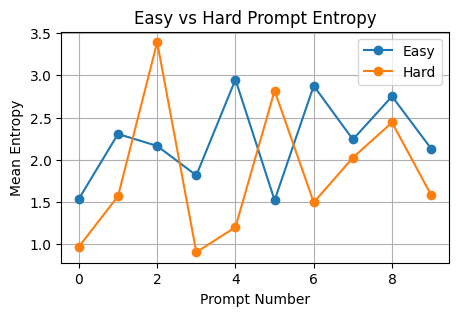

In [110]:
pyplot.figure(figsize=(5,3))

pyplot.plot(
    df1["mean_entropy"],
    marker='o',
    label='Easy'
)

pyplot.plot(
    df2["mean_entropy"],
    marker='o',
    label='Hard'
)

pyplot.xlabel("Prompt Number")
pyplot.ylabel("Mean Entropy")
pyplot.title("Easy vs Hard Prompt Entropy")

pyplot.legend()
pyplot.grid(True)

pyplot.show()

### **Graph Inference**

The entropy curves for the easy and hard prompt sets exhibit substantial overlap, with no consistent separation between the two categories. Several **hard** prompts produce entropy values comparable to, or even lower than, those of **easy** prompts. This suggests that token-level predictive uncertainty is not solely determined by the perceived difficulty of a question from a human perspective.

More importantly, the results indicate that a language model's uncertainty does not necessarily increase when confronted with prompts that require complex reasoning, arithmetic, or linguistic manipulation. Instead, the model often assigns highly concentrated probability distributions to its predicted tokens regardless of whether the resulting answer is correct.

This observation highlights a fundamental limitation of using entropy alone as a proxy for correctness:

**A language model can generate incorrect or hallucinated outputs while maintaining low entropy and high confidence.**

Consequently, hallucinations cannot be explained simply as instances of high uncertainty. The presence of low-entropy responses to challenging prompts suggests that many hallucinations may arise from overconfident predictions, where the model strongly favors an incorrect continuation despite lacking the knowledge or reasoning capability required to solve the task accurately.

## Does entropy differ between correct completions ad incorrect completions?

In [117]:
prompts=[   
    "Q: What is 2+2?\nA:",
    "Q: What is the freezing point of water?\nA:",
    "Q: Which is the largest planet?\nA:",
    "Q: What is the capital of India?\nA:",
    "Q: Is theory of relativity true?\nA:",
    "Q: Who is the president of India?\nA:",
    "Q: When did India gain independence?\nA:",
    "Q: What is the square root of 25 ?\nA:",
    "Q: Who won orange cap in IPL 2016?\nA:",
    "Q: How far is sun from earth?\nA:",
    "Q: I want to wash my car. The car wash is 50 m away. Should I walk or drive?\nA:",
    "Q: 779,678 * 866,978=?\nA:",
    "Q: What is 'elbow' spelled backwards?\nA:",
    "Q: I do not not not like eggs. Do I like eggs?\nA:",
    "Q: Sally is a girl. She has 3 brothers. Each brother has 2 sisters. How many sisters does Sally have?\nA:",
    "Q: Given a QWERTY keyboard layout, if HEART goes to JRSTY, what does AFTER go to?\nA:",
    "Q: Which word comes next: Stone, Often, Canine, _: A Helpful B Freight C Glow D Grape?\nA:",
    "Q: Five monkeys are jumping around on a four poster bed while three chickens stand and watch. How many legs are on the floor?\nA:",
    "Q: In a room there are only three sisters. Anna is reading a book. Alice is playing chess. What is the third sister, Amanda doing?\nA:",
    "Q: How many boxes do I have if I have two boxes with one box inside each?\nA:"
]

In [118]:
results = []

for prompt in prompts:
    stats= analyze_generation(prompt)
    stats["prompt"] = prompt
    results.append(stats)
df = pd.DataFrame(results)

In [119]:
print(df[["prompt", "generated_text", "mean_entropy"]])

                                               prompt  \
0                                 Q: What is 2+2?\nA:   
1         Q: What is the freezing point of water?\nA:   
2                 Q: Which is the largest planet?\nA:   
3                Q: What is the capital of India?\nA:   
4                Q: Is theory of relativity true?\nA:   
5               Q: Who is the president of India?\nA:   
6            Q: When did India gain independence?\nA:   
7              Q: What is the square root of 25 ?\nA:   
8              Q: Who won orange cap in IPL 2016?\nA:   
9                   Q: How far is sun from earth?\nA:   
10  Q: I want to wash my car. The car wash is 50 m...   
11                         Q: 779,678 * 866,978=?\nA:   
12          Q: What is 'elbow' spelled backwards?\nA:   
13  Q: I do not not not like eggs. Do I like eggs?...   
14  Q: Sally is a girl. She has 3 brothers. Each b...   
15  Q: Given a QWERTY keyboard layout, if HEART go...   
16  Q: Which word comes next: S

In [120]:
correctness=[
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    0,
    0,
    0,
    0,
    1,
    0
]

In [121]:
df["correct"]=correctness
correct_mean = df[
    df["correct"] == 1
]["mean_entropy"]

wrong_mean = df[
    df["correct"] == 0
]["mean_entropy"]

print("Correct: ", correct_mean.mean())
print("Incorrect: ", wrong_mean.mean())

Correct:  1.2899948659958318
Incorrect:  2.0369324172076047


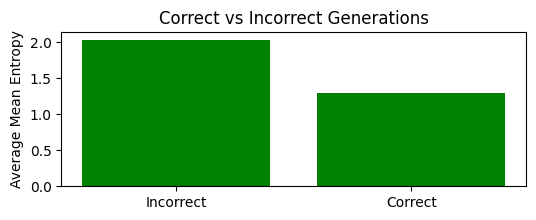

In [138]:
grouped = df.groupby(
    "correct"
)["mean_entropy"].mean()

pyplot.figure(figsize=(6, 2))
pyplot.bar(
    ["Incorrect","Correct"],
    [
        grouped[0],
        grouped[1],
    ],
    color='green'
    
)

pyplot.ylabel("Average Mean Entropy")
pyplot.title(
    "Correct vs Incorrect Generations"
)

pyplot.show()

### Graph Inference:
The entropy curves for the **correct** and **incorrect** generations exhibit substantial overlap, with no clear or consistent separation between the two categories. Several incorrect responses produce entropy values comparable to, or even lower than, those of correct responses. This indicates that token-level predictive uncertainty alone is not a reliable indicator of whether a generated answer will be factually correct.

More importantly, the results suggest that a language model's internal uncertainty does not necessarily increase when it produces an incorrect answer. In many cases, the model generates incorrect or hallucinated outputs while maintaining entropy levels similar to those observed for correct responses. This implies that the model often assigns highly concentrated probability distributions to its predictions regardless of their factual validity.

This observation highlights a fundamental limitation of entropy-based hallucination detection:

**Incorrect generations are not always accompanied by elevated uncertainty; a language model can be confidently wrong.**

Consequently, hallucinations cannot be viewed simply as the outcome of uncertain predictions. If incorrect generations consistently exhibited high entropy, hallucination detection would be relatively straightforward. However, the observed overlap between the two curves demonstrates that many errors arise from overconfident mispredictions, where the model strongly favors an incorrect continuation despite lacking the knowledge or reasoning capability required to produce the correct answer.

## Result:
These findings suggest that mean entropy alone is insufficient as a standalone hallucination detector. While entropy captures uncertainty in next-token prediction, it does not fully capture the model's factual reliability. Therefore, more informative indicators—such as maximum entropy, entropy spikes, minimum token probability, confidence calibration metrics, or combinations of multiple uncertainty measures—may be required to distinguish hallucinated outputs from correct generations.

Overall, the experiment provides evidence that correctness and uncertainty are related but not equivalent concepts, reinforcing the central challenge of hallucination detection: the most problematic errors are often those produced with high confidence and relatively low apparent uncertainty.